# Lesson 03 — Convolutional Neural Networks

> **Goal:** Understand convolutions, build a CNN, and see why it beats Dense layers on images.  
> **What you already know:** Dense layers, training loop, why flattening loses spatial info.  
> **What's new:** Conv2D, MaxPooling, feature maps, Dropout.

---

## The Core Idea

A Dense layer connects **every input to every output** — it has no concept of space.  
A Conv layer slides a small filter across the image — it only looks at **local patches**.  

This means:
- It preserves spatial structure
- It uses far fewer parameters (one filter shared across the whole image)
- It can detect the same pattern anywhere in the image (translation invariance)

---

In [1]:
import os
os.environ['TF_ENABLE_ONEDNN_OPTS'] = '0'
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '3'

import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt

print("TensorFlow:", tf.__version__)

TensorFlow: 2.21.0


---
## Step 1 — What a Convolution Actually Does

Before building a model, let's run a convolution manually on a real image.  
We'll use a hand-crafted filter so you can see exactly what it detects.

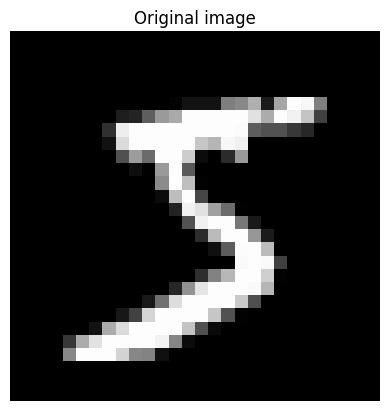

Image shape: (28, 28)


In [2]:
# Load one MNIST image
(x_train, _), _ = tf.keras.datasets.mnist.load_data()
img = x_train[0].astype('float32') / 255.0   # shape (28, 28)

plt.imshow(img, cmap='gray')
plt.title('Original image')
plt.axis('off')
plt.show()
print("Image shape:", img.shape)

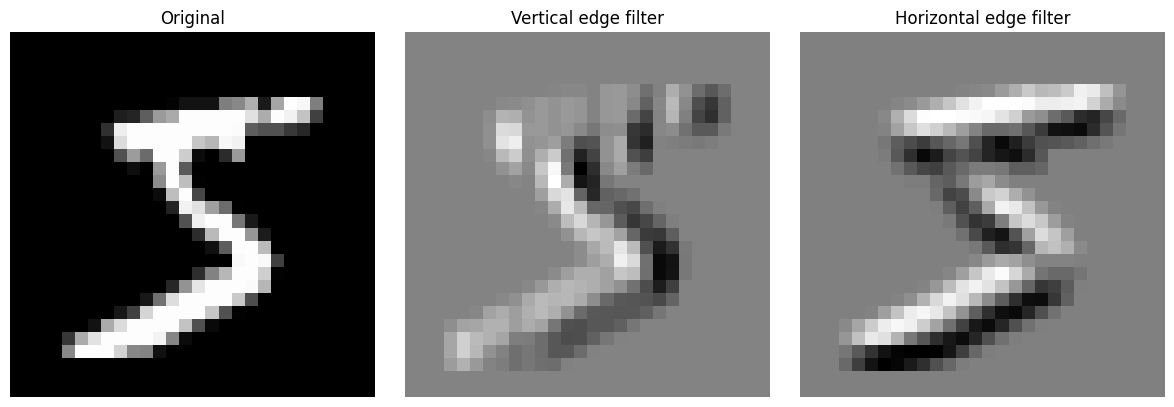

In [3]:
# Reshape for tf.nn.conv2d: needs (batch, height, width, channels)
img_tensor = img.reshape(1, 28, 28, 1)

# --- Filter 1: Vertical edge detector ---
# When this filter slides over a vertical edge, the dot product is large
# When it slides over flat regions, the dot product is near zero
vertical_filter = tf.constant([
    [-1,  0,  1],
    [-1,  0,  1],
    [-1,  0,  1]
], dtype=tf.float32)

# --- Filter 2: Horizontal edge detector ---
horizontal_filter = tf.constant([
    [-1, -1, -1],
    [ 0,  0,  0],
    [ 1,  1,  1]
], dtype=tf.float32)

# Reshape filters for tf.nn.conv2d: (height, width, in_channels, out_channels)
vf = vertical_filter.numpy().reshape(3, 3, 1, 1)
hf = horizontal_filter.numpy().reshape(3, 3, 1, 1)

# Apply convolutions
v_result = tf.nn.conv2d(img_tensor, vf, strides=1, padding='SAME')
h_result = tf.nn.conv2d(img_tensor, hf, strides=1, padding='SAME')

# Plot
fig, axes = plt.subplots(1, 3, figsize=(12, 4))
axes[0].imshow(img, cmap='gray')
axes[0].set_title('Original')
axes[1].imshow(v_result[0, :, :, 0], cmap='gray')
axes[1].set_title('Vertical edge filter')
axes[2].imshow(h_result[0, :, :, 0], cmap='gray')
axes[2].set_title('Horizontal edge filter')
for ax in axes: ax.axis('off')
plt.tight_layout()
plt.show()

**Look at the output carefully.**

The vertical filter lights up the left and right edges of strokes.  
The horizontal filter lights up the top and bottom edges.  

We hand-crafted these filters. In a real CNN, **the network learns these filters automatically** through gradient descent — we just tell it how many filters to use.

---
## Step 2 — Key CNN Concepts

### Conv2D
```python
tf.keras.layers.Conv2D(filters=32, kernel_size=3, activation='relu', padding='same')
```
- `filters=32` → learn 32 different filters, produces 32 feature maps
- `kernel_size=3` → each filter is 3×3
- `padding='same'` → output has same spatial size as input

### MaxPooling2D
```python
tf.keras.layers.MaxPooling2D(pool_size=2)
```
Takes a 2×2 patch and keeps only the **maximum value**.  
Halves the spatial dimensions: `(28, 28)` → `(14, 14)`  
Why: reduces computation, and makes detection slightly position-invariant.

```
1  3        3
2  4   →    (max of 2x2 patch)
```

### Dropout
```python
tf.keras.layers.Dropout(0.5)
```
During training, randomly sets 50% of neurons to zero.  
Forces the network to not rely on any single neuron — reduces overfitting.  
During inference (prediction), it's automatically turned off.

### Flatten
Converts the final 3D feature maps `(h, w, filters)` → 1D vector before Dense layers.

---
## Step 3 — Load and Preprocess Data

This time we do **not** flatten the images — CNNs need the 2D structure.

In [4]:
(x_train, y_train), (x_test, y_test) = tf.keras.datasets.mnist.load_data()

# Normalize
x_train = x_train / 255.0
x_test  = x_test  / 255.0

# Add channel dimension: (60000, 28, 28) → (60000, 28, 28, 1)
# Conv2D expects (batch, height, width, channels)
x_train = x_train[..., tf.newaxis]   # same as reshape(-1, 28, 28, 1)
x_test  = x_test[...,  tf.newaxis]

print("x_train shape:", x_train.shape)  # (60000, 28, 28, 1)
print("x_test shape: ", x_test.shape)

x_train shape: (60000, 28, 28, 1)
x_test shape:  (10000, 28, 28, 1)


---
## Step 4 — Build the CNN

```
Input (28, 28, 1)
    ↓
Conv2D(32, 3×3) + ReLU   → (28, 28, 32)   — 32 feature maps
    ↓
MaxPooling(2×2)           → (14, 14, 32)   — halve spatial dims
    ↓
Conv2D(64, 3×3) + ReLU   → (14, 14, 64)   — 64 feature maps
    ↓
MaxPooling(2×2)           → (7, 7, 64)     — halve again
    ↓
Flatten                   → (3136,)         — 7*7*64
    ↓
Dropout(0.5)              → kills 50% randomly during training
    ↓
Dense(128) + ReLU
    ↓
Dense(10) + Softmax       → 10 class probabilities
```

In [5]:
model = tf.keras.Sequential([
    # Block 1
    tf.keras.layers.Conv2D(32, kernel_size=3, activation='relu', padding='same', input_shape=(28, 28, 1)),
    tf.keras.layers.MaxPooling2D(pool_size=2),

    # Block 2
    tf.keras.layers.Conv2D(64, kernel_size=3, activation='relu', padding='same'),
    tf.keras.layers.MaxPooling2D(pool_size=2),

    # Classifier head
    tf.keras.layers.Flatten(),
    tf.keras.layers.Dropout(0.5),
    tf.keras.layers.Dense(128, activation='relu'),
    tf.keras.layers.Dense(10,  activation='softmax')
])

model.summary()

/mnt/c/Users/zenpu/OneDrive/Desktop/Python/face-detection-tf/venv/lib/python3.12/site-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 28, 28, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 14, 14, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 14, 14, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 7, 7, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 3136)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 3136)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       401,536 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 421,642 (1.61 MB)

 Trainable params: 421,642 (1.61 MB)

 Non-trainable params: 0 (0.00 B)

**Compare parameter counts with Lesson 02.**

Lesson 02 Dense network: ~105,000 parameters  
This CNN: far fewer in the conv layers — because one filter is shared across the whole image.

Conv2D(32, 3×3) param count:  
`(3 × 3 × 1) × 32 + 32 = 288 + 32 = 320`  
Just 320 parameters to scan the entire 28×28 image with 32 filters.

---
## Step 5 — Compile and Train

In [6]:
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

history = model.fit(
    x_train, y_train,
    batch_size=64,
    epochs=5,
    validation_split=0.1
)

Epoch 1/5
844/844 ━━━━━━━━━━━━━━━━━━━━ 11s 11ms/step - accuracy: 0.9385 - loss: 0.2012 - val_accuracy: 0.9845 - val_loss: 0.0558
Epoch 2/5
844/844 ━━━━━━━━━━━━━━━━━━━━ 9s 11ms/step - accuracy: 0.9775 - loss: 0.0708 - val_accuracy: 0.9900 - val_loss: 0.0370
Epoch 3/5
844/844 ━━━━━━━━━━━━━━━━━━━━ 10s 11ms/step - accuracy: 0.9831 - loss: 0.0529 - val_accuracy: 0.9897 - val_loss: 0.0383
Epoch 4/5
844/844 ━━━━━━━━━━━━━━━━━━━━ 9s 11ms/step - accuracy: 0.9861 - loss: 0.0427 - val_accuracy: 0.9907 - val_loss: 0.0347
Epoch 5/5
844/844 ━━━━━━━━━━━━━━━━━━━━ 8s 10ms/step - accuracy: 0.9883 - loss: 0.0356 - val_accuracy: 0.9912 - val_loss: 0.0303


---
## Step 6 — Evaluate and Compare

In [7]:
test_loss, test_acc = model.evaluate(x_test, y_test, verbose=0)
print(f"CNN Test accuracy: {test_acc:.4f}")
print(f"Dense Test accuracy (Lesson 02): ~0.9750")
print(f"Improvement: {(test_acc - 0.975)*100:.2f}%")

CNN Test accuracy: 0.9917
Dense Test accuracy (Lesson 02): ~0.9750
Improvement: 1.67%


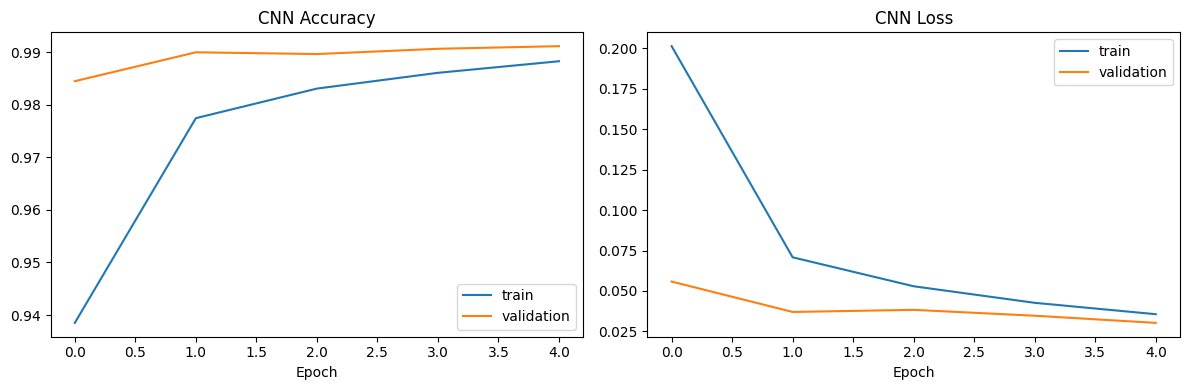

In [8]:
# Training curves
plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'],     label='train')
plt.plot(history.history['val_accuracy'], label='validation')
plt.title('CNN Accuracy')
plt.xlabel('Epoch')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history.history['loss'],     label='train')
plt.plot(history.history['val_loss'], label='validation')
plt.title('CNN Loss')
plt.xlabel('Epoch')
plt.legend()

plt.tight_layout()
plt.show()

---
## Step 7 — Visualize What the Filters Learned

The most important step. Let's see what the first Conv layer actually learned to detect.

Filter shape: (3, 3, 1, 32)


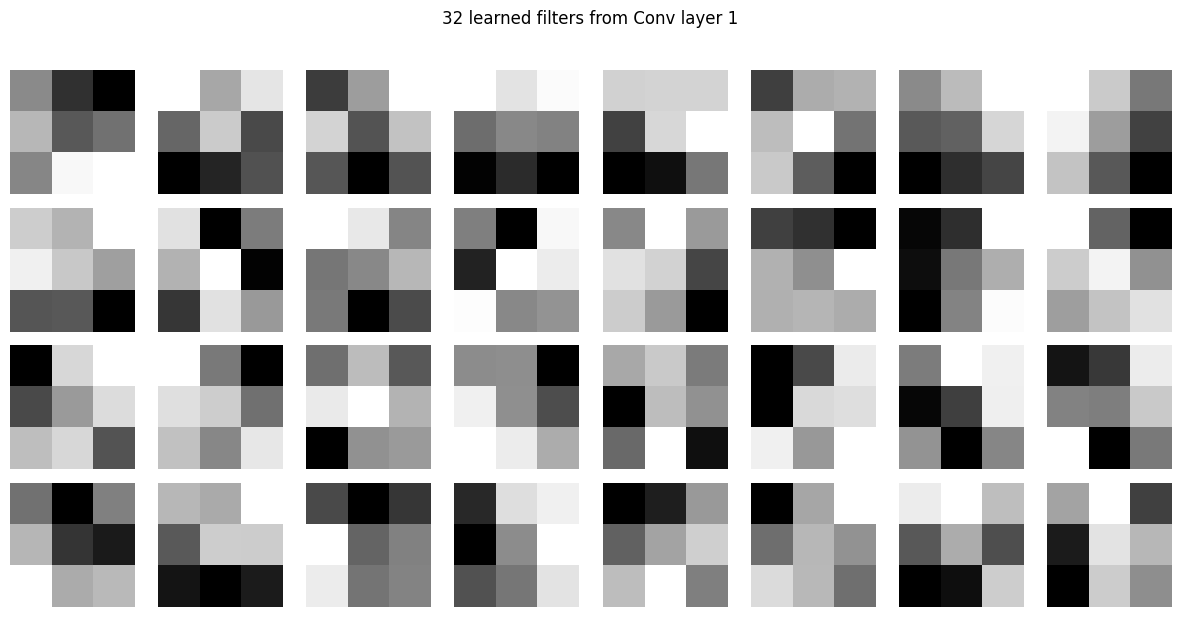

In [9]:
# Extract the first conv layer's filters
conv1_filters, conv1_biases = model.layers[0].get_weights()
print("Filter shape:", conv1_filters.shape)  # (3, 3, 1, 32) — 32 filters of 3x3

# Plot all 32 learned filters
fig, axes = plt.subplots(4, 8, figsize=(12, 6))
for i, ax in enumerate(axes.flat):
    f = conv1_filters[:, :, 0, i]
    ax.imshow(f, cmap='gray')
    ax.axis('off')
plt.suptitle('32 learned filters from Conv layer 1', y=1.02)
plt.tight_layout()
plt.show()

In [10]:
# Build a model that outputs the feature maps after layer 1
feature_map_model = tf.keras.Model(
    inputs=model.input,
    outputs=model.layers[0].output   # output of first Conv2D
)

# Pick one test image
sample = x_test[0:1]   # shape (1, 28, 28, 1)
feature_maps = feature_map_model.predict(sample)  # shape (1, 28, 28, 32)

# Plot the original and first 16 feature maps
fig, axes = plt.subplots(3, 6, figsize=(14, 7))

# Original
axes[0, 0].imshow(sample[0, :, :, 0], cmap='gray')
axes[0, 0].set_title('Original')
axes[0, 0].axis('off')
for ax in axes[0, 1:]: ax.axis('off')

# Feature maps
for i in range(16):
    row = (i // 6) + 1
    col = i % 6
    axes[row, col].imshow(feature_maps[0, :, :, i], cmap='viridis')
    axes[row, col].set_title(f'Filter {i}')
    axes[row, col].axis('off')

plt.suptitle('What each filter "sees" in the image')
plt.tight_layout()
plt.show()

AttributeError: The layer sequential has never been called and thus has no defined input.

**Look at the feature maps.**

Each one is the same image processed through a different filter.  
Some light up edges. Some light up curves. Some respond to specific stroke directions.  
The network figured all of this out on its own — we never told it what to look for.

This is exactly what will happen with face detection:  
Early layers → edges, textures  
Middle layers → eyes, nose shapes, curves  
Deep layers → face-like patterns

---
## ✅ Lesson 03 — Summary

| Concept | What you learned |
|---------|------------------|
| Convolution | Slide a filter across image → dot product at each position → feature map |
| `Conv2D(32, 3)` | Learn 32 filters of size 3×3. Params = `(3×3×channels + 1) × 32` |
| Feature map | Output of one filter applied to the whole image |
| `MaxPooling2D(2)` | Keep max in each 2×2 patch → halve spatial size |
| `Dropout(0.5)` | Randomly zero 50% of neurons during training → reduces overfitting |
| Parameter sharing | One filter scans the whole image — far fewer params than Dense |
| Translation invariance | Same filter detects a feature anywhere in the image |

---

## Think about these before Lesson 04:

1. In face detection, our output won't be 10 classes — it'll be **face or not face**. What changes in the output layer?
2. MNIST images are `28×28`. Face images will be much larger — say `224×224`. How does that affect the network depth?
3. We used 2 conv blocks here. Why might face detection need more?

---

## 🚀 Next: Lesson 04 — Face Detection (Pre-trained Model)
We'll use a pre-trained model to detect faces on your webcam in real time.  
Fast win. Then in Lesson 05, we build our own from scratch using everything we've learned.